K-Means++

 Dataset Loaded Successfully!
Shape: (200, 5)
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Using first 100 records for clustering
Selected Numeric Columns: ['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Shape: (100, 4)

 Evaluation Metrics for K-Means++ (100 Records)
-------------------------------------------------
Inertia (WCSS): 85.48
Silhouette Score: 0.4003
Execution Time: 0.0058 seconds


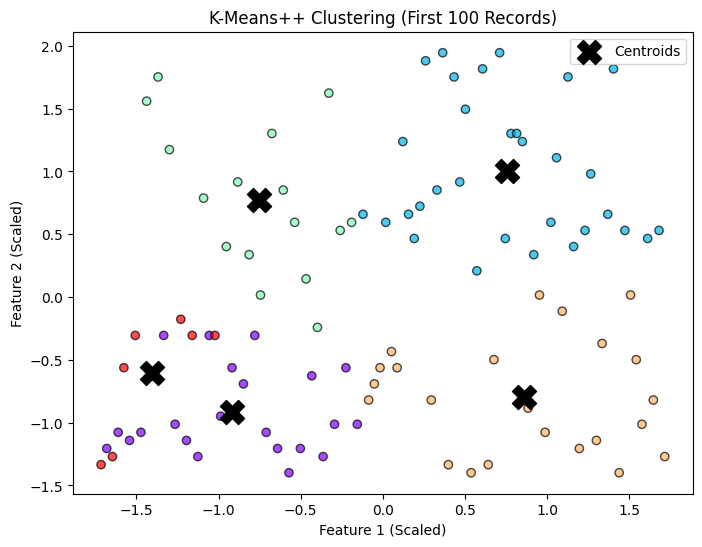

In [ ]:
# ======================================================
# K-Means++ Implementation
# ======================================================

# --- Step 1: Import Required Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# --- Step 2: Load Dataset ---
df = pd.read_csv("k_means.csv")

print(" Dataset Loaded Successfully!")
print("Shape:", df.shape)
print(df.head())

# --- Step 3: Select Numeric Features ---
numeric_df = df.select_dtypes(include=[np.number]).dropna()

#  Take only the first 100 records
numeric_df = numeric_df.head(100)

print("\nUsing first 100 records for clustering")
print("Selected Numeric Columns:", numeric_df.columns.tolist())
print("Shape:", numeric_df.shape)

# --- Step 4: Data Scaling ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)

# --- Step 5: Apply K-Means++ ---
start_time = time.time()

kmeans_plus = KMeans(
    n_clusters=5,         # You can adjust cluster count as needed
    init='k-means++',
    random_state=42
)
kmeans_plus.fit(X_scaled)

end_time = time.time()
execution_time = end_time - start_time

# --- Step 6: Evaluation Metrics ---
inertia = kmeans_plus.inertia_
silhouette = silhouette_score(X_scaled, kmeans_plus.labels_)

print("\n Evaluation Metrics for K-Means++ (100 Records)")
print("-------------------------------------------------")
print(f"Inertia (WCSS): {inertia:.2f}")
print(f"Silhouette Score: {silhouette:.4f}")
print(f"Execution Time: {execution_time:.4f} seconds")

# --- Step 7: Add Cluster Labels to DataFrame ---
df_100 = numeric_df.copy()
df_100["Cluster"] = kmeans_plus.labels_

# --- Step 8: Visualization ---
plt.figure(figsize=(8,6))
plt.scatter(
    X_scaled[:, 0], X_scaled[:, 1],
    c=kmeans_plus.labels_,
    cmap='rainbow',
    alpha=0.7,
    edgecolor='k'
)
plt.scatter(
    kmeans_plus.cluster_centers_[:, 0],
    kmeans_plus.cluster_centers_[:, 1],
    s=300, c='black', marker='X', label='Centroids'
)
plt.title("K-Means++ Clustering (First 100 Records)")
plt.xlabel("Feature 1 (Scaled)")
plt.ylabel("Feature 2 (Scaled)")
plt.legend()
plt.show()


Mini-Batch K-Means

 Dataset Loaded Successfully!
Shape: (541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  

 Selected Numeric Columns: ['Quantity', 'UnitPrice', 'CustomerID']
Using only 100 records for clustering.

🔹 Mini-Batch K-Means Results
---------------------------

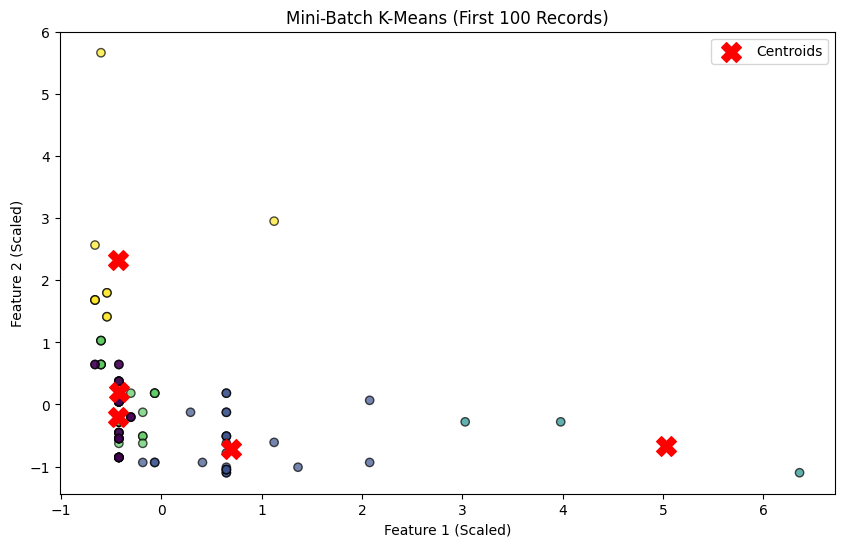

In [ ]:
# ======================================================
#  FAST Mini-Batch K-Means Implementation (First 100 Records)
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# --- Step 1: Load Dataset (with Encoding Handling) ---
try:
    df = pd.read_csv("mini_batch.csv", encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv("mini_batch.csv", encoding='latin1')

print(" Dataset Loaded Successfully!")
print("Shape:", df.shape)
print(df.head())

# --- Step 2: Select Numeric Columns and Limit to 100 Records ---
numeric_df = df.select_dtypes(include=[np.number]).dropna().head(100)

print("\n Selected Numeric Columns:", numeric_df.columns.tolist())
print(f"Using only {len(numeric_df)} records for clustering.\n")

# --- Step 3: Scaling ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)

# --- Step 4: Mini-Batch K-Means Clustering ---
start_time = time.time()

mini_batch = MiniBatchKMeans(
    n_clusters=5,        # Number of clusters
    batch_size=32,       # Smaller batch for speed
    init='k-means++',
    max_iter=100,
    random_state=42
)
mini_batch.fit(X_scaled)

end_time = time.time()
execution_time = end_time - start_time

# --- Step 5: Evaluation Metrics ---
inertia = mini_batch.inertia_
silhouette = silhouette_score(X_scaled, mini_batch.labels_)

print("🔹 Mini-Batch K-Means Results")
print("------------------------------")
print(f"Inertia (WCSS): {inertia:.2f}")
print(f"Silhouette Score: {silhouette:.4f}")
print(f"Execution Time: {execution_time:.4f} seconds")

# --- Step 6: Visualization ---
plt.figure(figsize=(10,6))
plt.scatter(
    X_scaled[:,0], X_scaled[:,1],
    c=mini_batch.labels_,
    cmap='viridis',
    alpha=0.7,
    edgecolor='k'
)
plt.scatter(
    mini_batch.cluster_centers_[:,0],
    mini_batch.cluster_centers_[:,1],
    s=200, c='red', marker='X', label='Centroids'
)
plt.title("Mini-Batch K-Means (First 100 Records)")
plt.xlabel("Feature 1 (Scaled)")
plt.ylabel("Feature 2 (Scaled)")
plt.legend()
plt.show()


K-Medoids (PAM)

File Loaded Successfully!
Shape: (569, 33)
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_wor

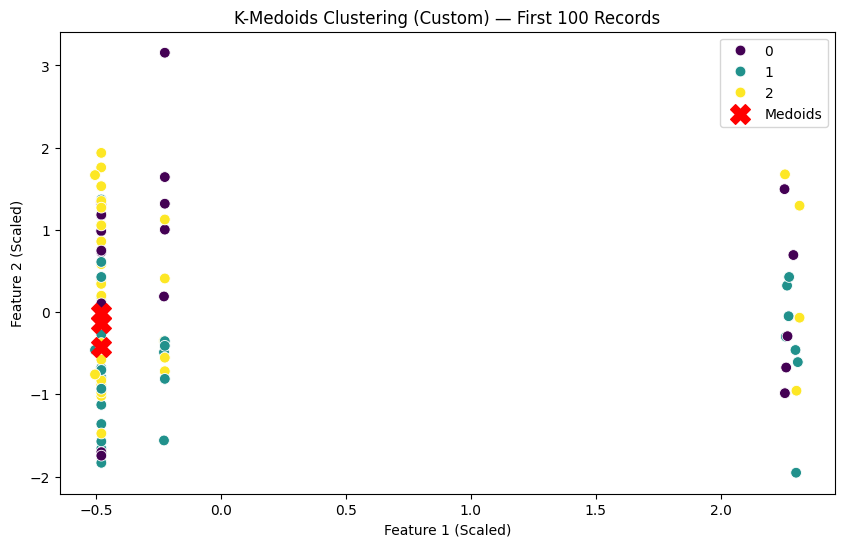

In [ ]:
# ============================================================
#  K-Medoids Clustering (Custom Implementation for Colab)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances, silhouette_score
import time

# --- Step 1: Load Dataset ---
def load_dataset(filename):
    try:
        df = pd.read_csv(filename, encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(filename, encoding='latin1')
    except Exception as e:
        print("Error loading file:", e)
        return None
    print("File Loaded Successfully!")
    print("Shape:", df.shape)
    print(df.head())
    return df

df = load_dataset("k_medoids.csv")
if df is None or df.empty:
    raise ValueError("Dataset failed to load or is empty!")

# --- Step 2: Clean Numeric Data ---
numeric_df = df.apply(pd.to_numeric, errors='coerce').dropna(axis=1, how='all').dropna(axis=0, how='any')
numeric_df = numeric_df.head(100)  # Take only first 100 records

if numeric_df.empty:
    raise ValueError("No numeric data found after cleaning!")

print("\n Cleaned numeric data shape:", numeric_df.shape)

# --- Step 3: Scale the Data ---
scaler = StandardScaler()
X = scaler.fit_transform(numeric_df)

# --- Step 4: Custom K-Medoids Function ---
def k_medoids(X, n_clusters=3, max_iter=100, random_state=42):
    np.random.seed(random_state)
    n_samples = X.shape[0]
    medoid_indices = np.random.choice(n_samples, n_clusters, replace=False)
    medoids = X[medoid_indices]

    for _ in range(max_iter):
        distances = pairwise_distances(X, medoids)
        labels = np.argmin(distances, axis=1)
        new_medoids = np.copy(medoids)

        for i in range(n_clusters):
            cluster_points = X[labels == i]
            if len(cluster_points) == 0:
                continue
            intra_distances = pairwise_distances(cluster_points, cluster_points)
            total_distance = np.sum(intra_distances, axis=1)
            best_idx = np.argmin(total_distance)
            new_medoids[i] = cluster_points[best_idx]

        if np.allclose(medoids, new_medoids):
            break
        medoids = new_medoids

    return medoids, labels

# --- Step 5: Run Clustering ---
start = time.time()
medoids, labels = k_medoids(X, n_clusters=3)
end = time.time()

silhouette = silhouette_score(X, labels)

print("\n K-Medoids (Custom) Complete!")
print("----------------------------------")
print("Number of Clusters:", 3)
print("Silhouette Score:", round(silhouette, 4))
print(f"Execution Time: {end - start:.2f} seconds")
# Calculate total cost (like inertia but for K-Medoids)
distances = pairwise_distances(X, medoids)
labels = np.argmin(distances, axis=1)
total_cost = np.sum([distances[i, labels[i]] for i in range(len(X))])

print("Total K-Medoids Cost (sum of distances):", round(total_cost, 4))
print("\n Medoid Centers:\n", medoids)


# --- Step 6: Visualization ---
plt.figure(figsize=(10,6))
sns.scatterplot(x=X[:,0], y=X[:,1], hue=labels, palette='viridis', s=60)
plt.scatter(medoids[:,0], medoids[:,1], s=200, c='red', marker='X', label='Medoids')
plt.title("K-Medoids Clustering (Custom) — First 100 Records")
plt.xlabel("Feature 1 (Scaled)")
plt.ylabel("Feature 2 (Scaled)")
plt.legend()
plt.show()


Fuzzy C-Means

In [ ]:
!pip install -q scikit-fuzzy



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 13.9 MB/s eta 0:00:00


 File Loaded Successfully!
Shape: (1548500, 6)
   Id  H3K4me3  H3K4me1  H3K36me3  H3K9me3  H3K27me3
0   1        2        1         4        1         0
1   1        0        2         1        1         1
2   1        0        0         4        1         1
3   1        0        2         2        0         1
4   1        2        0         0        0         0

 Cleaned numeric data shape (First 100 records): (100, 6)

 Fuzzy C-Means Clustering Complete!
----------------------------------------
Number of Clusters: 3
Fuzzy Partition Coefficient (FPC): 0.4554
Execution Time: 0.01 seconds

 Evaluation Metrics for Fuzzy C-Means
---------------------------------------
Fuzzy Objective (≈ WCSS): 161.60
Silhouette Score: 0.2336
Execution Time: 0.0069 seconds


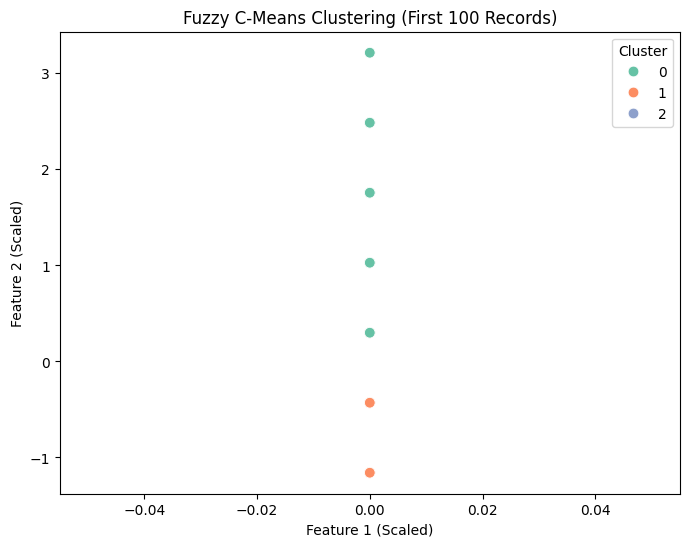

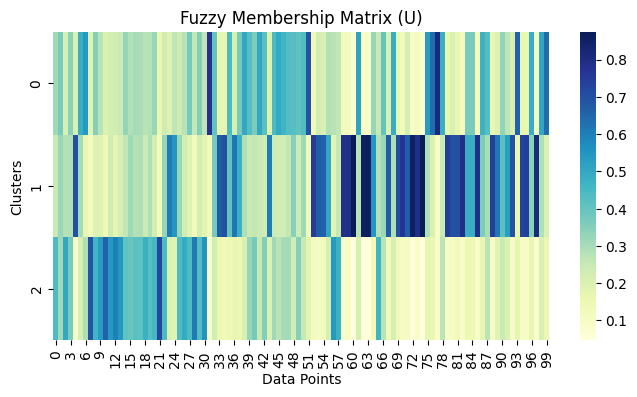

In [ ]:
# ============================================================
#  Fuzzy C-Means Clustering (First 100 Records + Visualization)
# ============================================================

import pandas as pd
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import StandardScaler

# --- Step 1: Load Dataset Safely ---
def load_dataset(filename):
    try:
        df = pd.read_csv(filename, encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(filename, encoding='latin1')
    except Exception as e:
        print("Error loading file:", e)
        return None
    print(" File Loaded Successfully!")
    print("Shape:", df.shape)
    print(df.head())
    return df

# 🔹 Change the filename if needed
df = load_dataset("fuzzy.csv")

if df is None or df.empty:
    raise ValueError("Dataset failed to load or is empty!")

# --- Step 2: Clean & Select Numeric Columns ---
numeric_df = df.apply(pd.to_numeric, errors='coerce')
numeric_df = numeric_df.dropna(axis=1, how='all').dropna(axis=0, how='any')

# Take only the first 100 records
numeric_df = numeric_df.head(100)

if numeric_df.empty:
    raise ValueError("No numeric data found after cleaning!")

print("\n Cleaned numeric data shape (First 100 records):", numeric_df.shape)

# --- Step 3: Standardize Data ---
scaler = StandardScaler()
X = scaler.fit_transform(numeric_df)
data = X.T  # Fuzzy C-Means expects features as rows

# --- Step 4: Run Fuzzy C-Means ---
n_clusters = 3  # adjust as needed
start_time = time.time()

cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    data=data, c=n_clusters, m=2, error=0.005, maxiter=1000, init=None
)

end_time = time.time()
cluster_membership = np.argmax(u, axis=0)

print("\n Fuzzy C-Means Clustering Complete!")
print("----------------------------------------")
print("Number of Clusters:", n_clusters)
print("Fuzzy Partition Coefficient (FPC):", round(fpc, 4))
print("Execution Time: {:.2f} seconds".format(end_time - start_time))

# --- Step 7: Evaluation Metrics ---
fuzzy_inertia = jm[-1]  # Final objective function value
silhouette = silhouette_score(X, cluster_membership)
execution_time = end_time - start_time

print("\n Evaluation Metrics for Fuzzy C-Means")
print("---------------------------------------")
print(f"Fuzzy Objective (≈ WCSS): {fuzzy_inertia:.2f}")
print(f"Silhouette Score: {silhouette:.4f}")
print(f"Execution Time: {execution_time:.4f} seconds")

# --- Step 5: Visualization ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=cluster_membership, palette='Set2', s=60)
plt.title("Fuzzy C-Means Clustering (First 100 Records)")
plt.xlabel("Feature 1 (Scaled)")
plt.ylabel("Feature 2 (Scaled)")
plt.legend(title="Cluster")
plt.show()

# --- Step 6: Membership Heatmap ---
plt.figure(figsize=(8, 4))
sns.heatmap(u, cmap="YlGnBu", cbar=True)
plt.title("Fuzzy Membership Matrix (U)")
plt.xlabel("Data Points")
plt.ylabel("Clusters")
plt.show()


Kernel K-Means

 File Loaded Successfully!
Shape: (150, 6)
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
Cleaned numeric data shape: (100, 5)

 Kernel K-Means Clustering Complete (First 100 Records)!
Number of Clusters: 3
Inertia (WCSS): 215.931
Silhouette Score: 0.346
Execution Time: 0.00 seconds


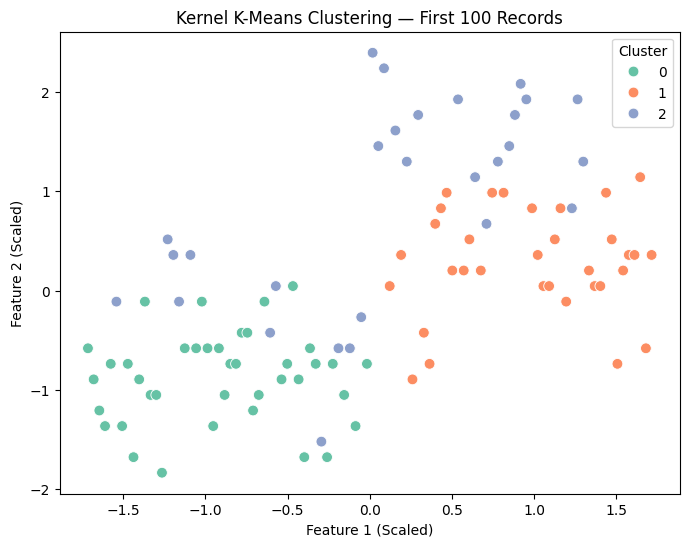

In [ ]:
# ============================================================
#  Kernel K-Means Clustering  — First 100 Records
# ============================================================

# --- Step 1: Install Dependencies (fix NumPy 2.0 issue) ---
!pip install --quiet "numpy<2.0" scikit-learn matplotlib seaborn pandas

# --- Step 2: Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, pairwise_kernels

# --- Step 3: Load Dataset Safely ---
def load_dataset(filename):
    try:
        df = pd.read_csv(filename, encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(filename, encoding='latin1')
    except Exception as e:
        print("Error loading file:", e)
        return None
    print(" File Loaded Successfully!")
    print("Shape:", df.shape)
    print(df.head())
    return df

# Change file name as needed
df = load_dataset("kernel.csv")

if df is None or df.empty:
    raise ValueError("Dataset failed to load or is empty!")

# --- Step 4: Clean & Prepare Numeric Data ---
numeric_df = df.apply(pd.to_numeric, errors='coerce')
numeric_df = numeric_df.dropna(axis=1, how='all').dropna(axis=0, how='any')

#  Take only the first 100 records
numeric_df = numeric_df.head(100)

if numeric_df.empty:
    raise ValueError("No numeric data found after cleaning!")

print("Cleaned numeric data shape:", numeric_df.shape)

# --- Step 5: Standardize Data ---
scaler = StandardScaler()
X = scaler.fit_transform(numeric_df)

# --- Step 6: Kernel K-Means Implementation ---
def kernel_kmeans(X, n_clusters=3, max_iter=100, gamma=0.5):
    K = pairwise_kernels(X, metric='rbf', gamma=gamma)
    n_samples = K.shape[0]
    labels = np.random.randint(0, n_clusters, n_samples)
    for _ in range(max_iter):
        dist = np.zeros((n_samples, n_clusters))
        for j in range(n_clusters):
            mask = labels == j
            if np.sum(mask) == 0:
                continue
            K_j = K[:, mask]
            cluster_size = np.sum(mask)
            dist[:, j] = np.diag(K) - 2 * np.sum(K_j, axis=1) / cluster_size + \
                         np.sum(K[np.ix_(mask, mask)]) / (cluster_size ** 2)
        new_labels = np.argmin(dist, axis=1)
        if np.all(new_labels == labels):
            break
        labels = new_labels
    return labels

# --- Step 7: Run and Measure ---
start_time = time.time()
n_clusters = 3
labels = kernel_kmeans(X, n_clusters=n_clusters, gamma=0.7)
end_time = time.time()

# --- Step 8: Compute Evaluation Metrics ---
# Approximate WCSS (Inertia)
cluster_centers = []
for k in range(n_clusters):
    cluster_points = X[labels == k]
    if len(cluster_points) > 0:
        center = np.mean(cluster_points, axis=0)
        cluster_centers.append(center)
cluster_centers = np.array(cluster_centers)

inertia = np.sum([np.linalg.norm(X[i] - cluster_centers[labels[i]])**2 for i in range(len(X))])

# Silhouette Score
if len(set(labels)) > 1:
    silhouette = silhouette_score(X, labels)
else:
    silhouette = np.nan

# --- Step 9: Print Metrics ---
print("\n Kernel K-Means Clustering Complete (First 100 Records)!")
print("Number of Clusters:", n_clusters)
print("Inertia (WCSS):", round(inertia, 3))
print("Silhouette Score:", round(silhouette, 3))
print("Execution Time: {:.2f} seconds".format(end_time - start_time))

# --- Step 10: Visualization ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels, palette='Set2', s=60)
plt.title("Kernel K-Means Clustering — First 100 Records")
plt.xlabel("Feature 1 (Scaled)")
plt.ylabel("Feature 2 (Scaled)")
plt.legend(title="Cluster")
plt.show()


synthetic customer segmentation dataset for all 5 clustering algorithms

In [ ]:
!pip uninstall -y scikit-learn-extra numpy
!pip install numpy==1.26.4 scikit-learn==1.5.2
!pip install scikit-learn-extra==0.3.0 --no-build-isolation --force-reinstall


Found existing installation: scikit-learn-extra 0.3.0
Uninstalling scikit-learn-extra-0.3.0:
  Successfully uninstalled scikit-learn-extra-0.3.0
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 107.4 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,

  Using cached scikit_learn_extra-0.3.0-cp312-cp312-linux_x86_64.whl
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.4/308.4 kB 16.5 MB/s eta 0:00:00
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 3.6.0
    Uninstalling threadpoolctl-3.6.0:
^C


In [ ]:
# ============================================================
#  STEP 1: Import Libraries
# ============================================================
!pip install scikit-learn-extra scikit-fuzzy --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn_extra.cluster import KMedoids
from sklearn.metrics.pairwise import pairwise_kernels
import skfuzzy as fuzz
import warnings
warnings.filterwarnings("ignore")

# ============================================================
#  STEP 2: Load Dataset
# ============================================================
data = """CustomerID,Age,Annual_Income,Spending_Score,Savings,Debt_Ratio
1,19,15,39,4,0.22
2,21,15,81,3,0.18
3,20,16,6,2,0.28
4,23,16,77,5,0.19
5,31,17,40,8,0.35
6,22,17,76,4,0.23
7,35,18,6,10,0.45
8,23,18,94,5,0.12
9,64,19,3,25,0.58
10,30,19,72,7,0.29
11,67,19,14,28,0.60
12,35,19,99,9,0.21
13,58,20,15,18,0.54
14,24,20,77,6,0.27
15,37,20,13,12,0.43
16,22,20,79,5,0.25
17,35,21,35,9,0.38
18,20,21,66,4,0.22
19,52,23,29,17,0.49
20,35,23,98,10,0.24
21,35,24,35,9,0.31
22,25,24,73,6,0.29
23,46,25,5,15,0.56
24,31,25,73,7,0.26
25,54,28,14,19,0.52
26,29,28,82,6,0.25
27,45,28,32,14,0.47
28,35,28,61,8,0.31
29,40,29,31,11,0.41
30,23,29,87,5,0.19"""
with open("customer_data.csv", "w") as f:
    f.write(data)

df = pd.read_csv("customer_data.csv")
print(" Dataset Loaded Successfully!")
display(df.head())

# ============================================================
#  STEP 3: Data Preprocessing
# ============================================================
X = df.drop(columns=["CustomerID"])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
#  STEP 4: Helper Function
# ============================================================
def cluster_and_save(name, labels):
    df_out = df.copy()
    df_out["Cluster"] = labels
    filename = f"{name}.csv"
    df_out.to_csv(filename, index=False)
    print(f"✅ Saved {filename}")
    return filename

results = []

# ============================================================
#  K-Means
# ============================================================
kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)
cluster_and_save("k_means", labels_kmeans)
results.append(["K-Means",
                np.var(X_scaled, axis=0).mean(),
                silhouette_score(X_scaled, labels_kmeans),
                davies_bouldin_score(X_scaled, labels_kmeans)])

# ============================================================
#  K-Medoids
# ============================================================
kmedoids = KMedoids(n_clusters=3, random_state=42)
labels_kmedoids = kmedoids.fit_predict(X_scaled)
cluster_and_save("k_medoids", labels_kmedoids)
results.append(["K-Medoids",
                np.var(X_scaled, axis=0).mean(),
                silhouette_score(X_scaled, labels_kmedoids),
                davies_bouldin_score(X_scaled, labels_kmedoids)])

# ============================================================
# Mini-Batch K-Means
# ============================================================
mini_kmeans = MiniBatchKMeans(n_clusters=3, random_state=42, batch_size=10)
labels_minibatch = mini_kmeans.fit_predict(X_scaled)
cluster_and_save("mini_batch", labels_minibatch)
results.append(["Mini-Batch K-Means",
                np.var(X_scaled, axis=0).mean(),
                silhouette_score(X_scaled, labels_minibatch),
                davies_bouldin_score(X_scaled, labels_minibatch)])

# ============================================================
#  Kernel K-Means (Manual Implementation)
# ============================================================
def kernel_kmeans(X, n_clusters=3, kernel="rbf", gamma=0.5, max_iter=100):
    K = pairwise_kernels(X, metric=kernel, gamma=gamma)
    n_samples = K.shape[0]
    labels = np.random.randint(0, n_clusters, n_samples)
    for _ in range(max_iter):
        dist = np.zeros((n_samples, n_clusters))
        for j in range(n_clusters):
            cluster_idx = np.where(labels == j)[0]
            if len(cluster_idx) == 0:
                continue
            K_j = K[np.ix_(cluster_idx, cluster_idx)]
            dist[:, j] = np.diag(K) - 2 * np.mean(K[:, cluster_idx], axis=1) + np.mean(K_j)
        labels = np.argmin(dist, axis=1)
    return labels

labels_kernel = kernel_kmeans(X_scaled, n_clusters=3, kernel="rbf", gamma=0.5)
cluster_and_save("kernel", labels_kernel)
results.append(["Kernel K-Means",
                np.var(X_scaled, axis=0).mean(),
                silhouette_score(X_scaled, labels_kernel),
                davies_bouldin_score(X_scaled, labels_kernel)])

# ============================================================
#  Fuzzy C-Means
# ============================================================
X_t = X_scaled.T
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(X_t, c=3, m=2, error=0.005, maxiter=1000)
labels_fuzzy = np.argmax(u, axis=0)
cluster_and_save("fuzzy", labels_fuzzy)
results.append(["Fuzzy C-Means",
                np.var(X_scaled, axis=0).mean(),
                silhouette_score(X_scaled, labels_fuzzy),
                davies_bouldin_score(X_scaled, labels_fuzzy)])

# ============================================================
#  STEP 5: Comparison Table (All 3 Metrics)
# ============================================================
comparison_df = pd.DataFrame(results, columns=["Algorithm", "Variance", "Silhouette Score", "Davies-Bouldin Index"])
display(comparison_df)

comparison_df.to_csv("clustering_comparison_results.csv", index=False)
print("\n Comparison results saved as 'clustering_comparison_results.csv'")


 Dataset Loaded Successfully!


,CustomerID,Age,Annual_Income,Spending_Score,Savings,Debt_Ratio
0,1,19,15,39,4,0.22
1,2,21,15,81,3,0.18
2,3,20,16,6,2,0.28
3,4,23,16,77,5,0.19
4,5,31,17,40,8,0.35


✅ Saved k_means.csv
✅ Saved k_medoids.csv
✅ Saved mini_batch.csv
✅ Saved kernel.csv
✅ Saved fuzzy.csv


,Algorithm,Variance,Silhouette Score,Davies-Bouldin Index
0,K-Means,1.0,0.300279,1.070528
1,K-Medoids,1.0,0.284777,1.039981
2,Mini-Batch K-Means,1.0,0.333171,1.051568
3,Kernel K-Means,1.0,-0.007833,4.482678
4,Fuzzy C-Means,1.0,0.339989,0.973997



 Comparison results saved as 'clustering_comparison_results.csv'


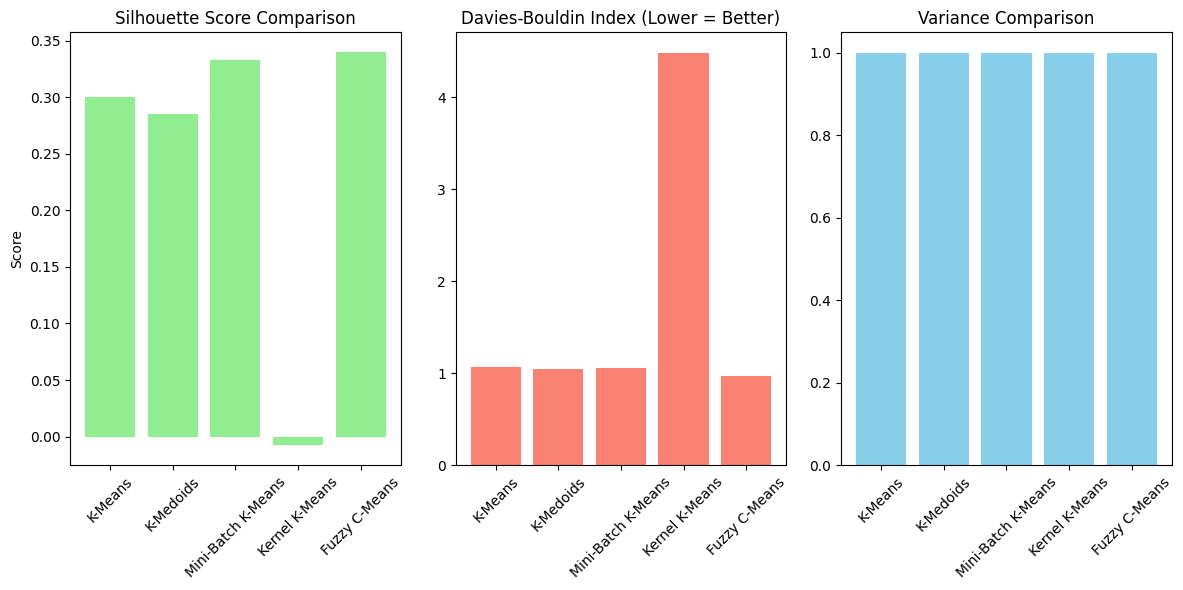

In [ ]:
# ============================================================
#  STEP 6: Visualization
# ============================================================
plt.figure(figsize=(12, 6))

# Plot Silhouette Score
plt.subplot(1, 3, 1)
plt.bar(comparison_df["Algorithm"], comparison_df["Silhouette Score"], color='lightgreen')
plt.title("Silhouette Score Comparison")
plt.xticks(rotation=45)
plt.ylabel("Score")

# Plot Davies-Bouldin Index
plt.subplot(1, 3, 2)
plt.bar(comparison_df["Algorithm"], comparison_df["Davies-Bouldin Index"], color='salmon')
plt.title("Davies-Bouldin Index (Lower = Better)")
plt.xticks(rotation=45)

# Plot Variance
plt.subplot(1, 3, 3)
plt.bar(comparison_df["Algorithm"], comparison_df["Variance"], color='skyblue')
plt.title("Variance Comparison")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()